In [2]:
from importlib import reload

import os, sys
from pathlib import Path
import json
import time
from tqdm import tqdm

import pandas as pd 
import numpy as np

# Can't use __file__ or __filename__ inside a Jupyter notebook
WORK_DIR = Path.cwd().parent

sys.path.append(str(WORK_DIR))

from src import (
    graph_gen,
    ollama_manager,
    video_tools,
    prompt_formatters,
    datasets,
)

from src.STAR_utils.visualization_tools import qa_visualization as qavis

from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO


In [41]:
STAR_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"
STAR_SMALL_200 = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_200.json"

VIDEO_DIR = WORK_DIR / "data/datasets/action-genome/Charades_v1_480"
VIDEO_DUMP_DIR = WORK_DIR / "experiments/video_dump"
video_ids = [{'video_id': "ATV2F"}]
video_path = VIDEO_DIR / "ATV2F.mp4"


## Initializing images

In [105]:
duration = float(video_tools.get_video_stream_info(video_path)['duration'])
video_ids[0]['start'] = 0.0
video_ids[0]['end'] = 4.0
video_ids[0]['question_id'] = "TEST_01"


In [106]:
qavis.Vis_Video(video_ids[0], VIDEO_DIR, VIDEO_DUMP_DIR)


	Video Seg:  0.0s - 4.0s


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

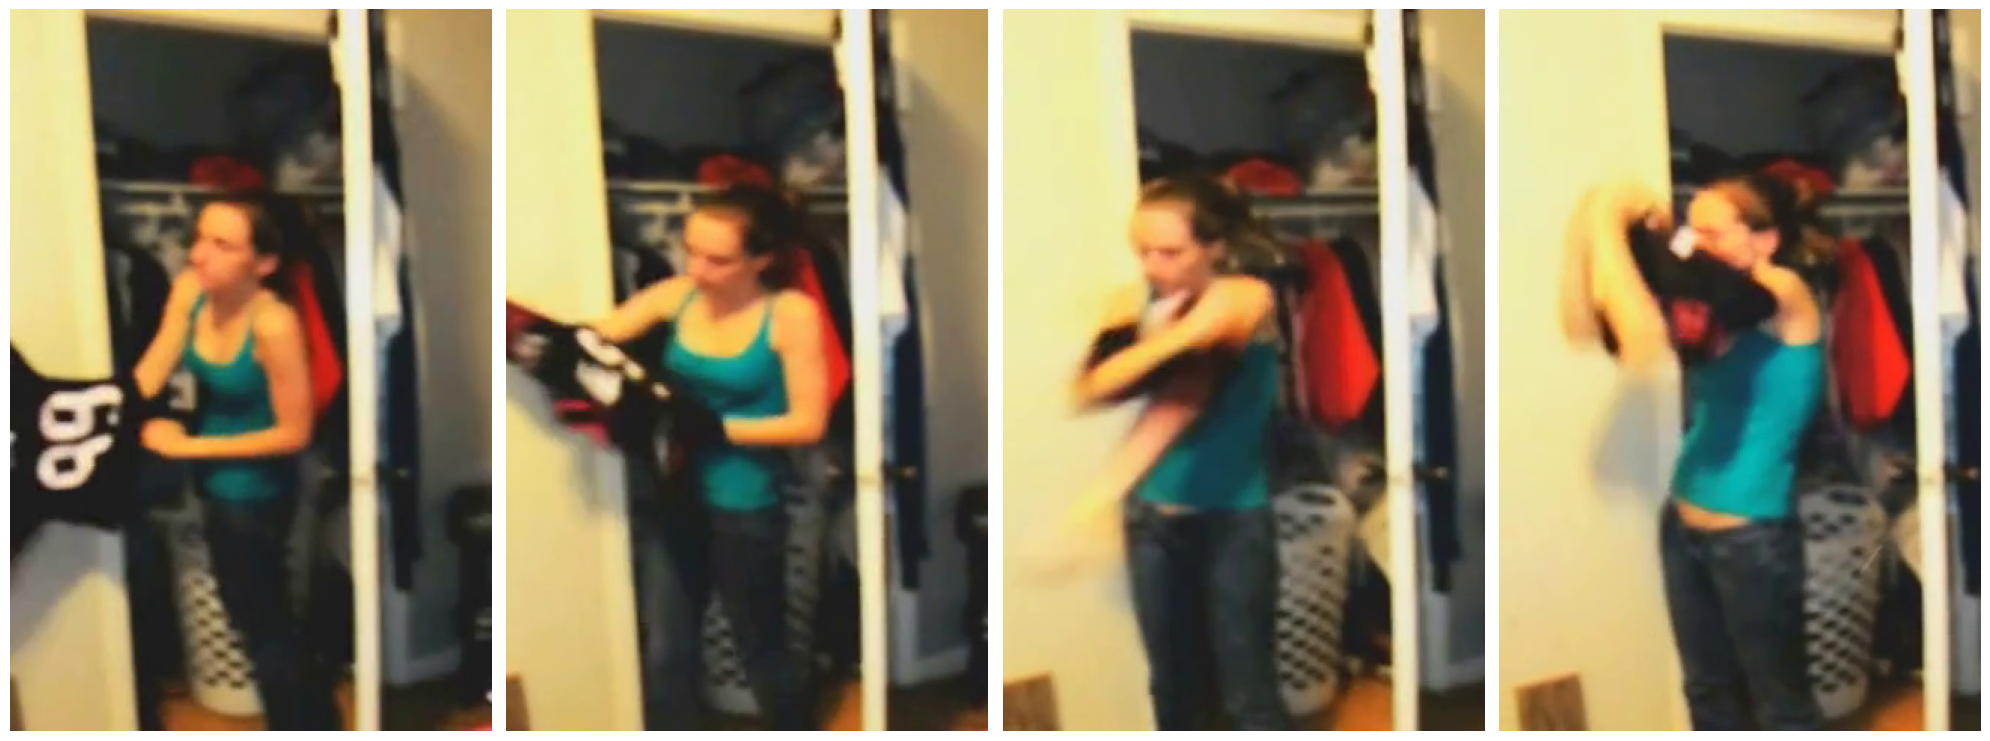

In [107]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

frame_dir, frame_paths = video_tools.extract_frames(video_path, fps=1, start_time=0, end_time=4,max_frames=10)
images = frame_paths
fig, axes = plt.subplots(1,  len(images), figsize=(20, 12))

for ax, img_path in zip(axes, images):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [108]:
fps = 1
video_frames_data = video_tools.generate_frames(
    VIDEO_DIR, 
    video_info=video_ids,
    fps=fps)
video_encodings = list(frames for frames in video_frames_data)
len(video_encodings)


1

In [109]:
_, frame_paths = video_tools.extract_frames(video_path, fps=1, start_time=0, end_time=4,max_frames=10)
images = [Image.open(frame_path) for frame_path in frame_paths]
images # Pillow images can be directly passed as inputs (which will be converted by the SDK)


[<PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x480>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x480>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x480>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x480>]

## Gemini API

In [27]:
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", None)
GEMINI_API_KEY2 = os.environ.get("GEMINI_API_KEY2", None)

# low safety settings
safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]
config = types.GenerateContentConfig(
    #thinking_config=types.ThinkingConfig(thinking_budget=0), # Disables thinking
    safety_settings=safety_settings,
    
)
client = genai.Client(
    api_key=GEMINI_API_KEY
)


### Tests

#### Remote resources

In [48]:
for i in client.files.list():
    print(i)
if False:
    for i in client.files.list():
        client.files.delete(name=i.name)


name='files/bqcc0hjmlc02' display_name='batch-gu_200_gemini_on_gemini_sgg_chunk_02' mime_type='jsonl' size_bytes=253264 create_time=datetime.datetime(2025, 7, 31, 22, 14, 51, 803165, tzinfo=TzInfo(UTC)) expiration_time=datetime.datetime(2025, 8, 2, 22, 14, 51, 149173, tzinfo=TzInfo(UTC)) update_time=datetime.datetime(2025, 7, 31, 22, 14, 51, 803165, tzinfo=TzInfo(UTC)) sha256_hash='N2EwZTUxYmFjNmIwODMzMWQxYjZiYWE4NmUyODlkMzI5NGExNTk4ODBhOWUzODc3MWM1MWZmYTJiNzdkY2RhMA==' uri='https://generativelanguage.googleapis.com/v1beta/files/bqcc0hjmlc02' download_uri=None state=<FileState.ACTIVE: 'ACTIVE'> source=<FileSource.UPLOADED: 'UPLOADED'> video_metadata=None error=None
name='files/56z86j9ka4di' display_name='batch-gu_200_gemini_on_gemini_sgg_chunk_01' mime_type='jsonl' size_bytes=250736 create_time=datetime.datetime(2025, 7, 31, 22, 14, 51, 724222, tzinfo=TzInfo(UTC)) expiration_time=datetime.datetime(2025, 8, 2, 22, 14, 51, 7197, tzinfo=TzInfo(UTC)) update_time=datetime.datetime(2025, 7, 

In [47]:
for job in client.batches.list(config=types.ListBatchJobsConfig(page_size=10)):
    print(job)

if False:
    for job in client.batches.list(config=types.ListBatchJobsConfig(page_size=100)):
        client.batches.delete(name=job.name)


name='batches/3dbgdhaeyfftf0njkd56k2esoppgq7oa08sz' display_name='batch-job-batch-gu_200_gemini_on_gemini_sgg_chunk_01' state=<JobState.JOB_STATE_PENDING: 'JOB_STATE_PENDING'> error=None create_time=datetime.datetime(2025, 7, 31, 22, 14, 52, 390519, tzinfo=TzInfo(UTC)) start_time=None end_time=None update_time=datetime.datetime(2025, 7, 31, 22, 14, 52, 390519, tzinfo=TzInfo(UTC)) model='models/gemini-2.5-flash' src=None dest=None
name='batches/jam08606qp6y1qn2p0v7tx9b0k4i6c5s5eqw' display_name='batch-job-batch-gu_200_gemini_on_gemini_sgg_chunk_02' state=<JobState.JOB_STATE_PENDING: 'JOB_STATE_PENDING'> error=None create_time=datetime.datetime(2025, 7, 31, 22, 14, 52, 310690, tzinfo=TzInfo(UTC)) start_time=None end_time=None update_time=datetime.datetime(2025, 7, 31, 22, 14, 52, 310690, tzinfo=TzInfo(UTC)) model='models/gemini-2.5-flash' src=None dest=None


In [24]:
batch_job = client.batches.get(name="batches/18czmehfq0ucs7eyfygdbfjb4blslddwuxft")


In [23]:
client.batches.delete(name="batches/3n97bndg5x2471iri9jrq4yhysy5t94jp1fr")


DeleteResourceJob()

In [11]:
batch_job.display_name


'batch-job-batch-test_chunk_02'

#### Look at the response file

In [40]:
INP_FILE = WORK_DIR / "scripts/data/vqa_gemini_flash_chunk_01_2nd.jsonl"
chunked_input = pd.read_json(INP_FILE, lines=True)

with open(INP_FILE) as f:
    str_repr = [line for line in f.readlines()]
chunked_input.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   key       50 non-null     object
 1   request   50 non-null     object
 2   response  50 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


In [ ]:
chunked_input.iloc[0]['request']['generationConfig']


{'thinkingConfig': {'thinkingBudget': 0, 'includeThoughts': True},
 'maxOutputTokens': 1024,
 'seed': 6}

In [ ]:
RESP_FILE = WORK_DIR / "scripts/outputs/.."
chunked_response = pd.read_json(RESP_FILE, lines=True)

chunked_response.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   key         50 non-null     object
 1   request     50 non-null     object
 2   response_x  50 non-null     object
 3   response_y  50 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB


In [ ]:
print(chunked_response.iloc[0].keys())
print(chunked_response.iloc[0]['response'].keys())


Index(['response', 'key'], dtype='object')
dict_keys(['candidates', 'modelVersion', 'usageMetadata', 'responseId'])


In [ ]:
chunked_response.iloc[0]['response']['usageMetadata']


{'promptTokenCount': 7104,
 'candidatesTokenCount': 16,
 'totalTokenCount': 7120,
 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 1428},
  {'tokenCount': 5676, 'modality': 'IMAGE'}]}

In [17]:
(
    chunked_response['response']
    .apply(lambda x: x['usageMetadata']['candidatesTokenCount'])
    .sum()
) / chunked_response.shape[0]


19.16

In [ ]:
chunked_response.iloc[1]['response']['candidates'][0]['content']['parts'][0]['text']


'{"answer": "C. Opened the closet/cabinet."}'

In [8]:
RESP_FILE = WORK_DIR / "scripts/test_data/sgg_test_output_chunk_01_2nd_chat_history.jsonl"
chunked_response = pd.read_json(RESP_FILE, lines=True)

chunked_response.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   key         5 non-null      object
 1   request     5 non-null      object
 2   response_x  5 non-null      object
 3   response_y  5 non-null      object
dtypes: object(4)
memory usage: 288.0+ bytes


In [ ]:
chunked_response.iloc[2]['key']


'Interaction_T1_9123'

In [ ]:
chunked_response.iloc[0]['response_x']


{'responseId': 'cDeKaJfEIc2o1MkP3dbNoAI',
 'usageMetadata': {'totalTokenCount': 6988,
  'promptTokensDetails': [{'tokenCount': 496, 'modality': 'TEXT'},
   {'modality': 'IMAGE', 'tokenCount': 5676}],
  'candidatesTokenCount': 816,
  'promptTokenCount': 6172},
 'modelVersion': 'gemini-2.5-flash',
 'candidates': [{'index': 0,
   'finishReason': 'STOP',
   'content': {'role': 'model',
    'parts': [{'text': 'Here\'s a detailed analysis of the video frames and the prediction of the person\'s next action:\n\n**1. Question Interpretation:**\nThe question asks to predict the next action the person in the video will perform, based on the provided sequence of images.\n\n**2. Video Analysis:**\nThe video shows a person in a kitchen setting.\n*   **Frames 1-4:** The view is partially obstructed by what appears to be a hand or arm, possibly from the camera being held by the person. The person is largely obscured but moving.\n*   **Frame 5:** The person becomes more visible. They are a man with a b

In [ ]:
chunked_response.iloc[0]['response_y']


{'candidates': [{'finishReason': 'STOP',
   'content': {'parts': [{'text': '```json\n{"answer": "B. Close the refrigerator."}\n```'}],
    'role': 'model'},
   'index': 0}],
 'modelVersion': 'gemini-2.5-flash',
 'usageMetadata': {'promptTokenCount': 7104,
  'candidatesTokenCount': 16,
  'totalTokenCount': 7120,
  'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 1428},
   {'tokenCount': 5676, 'modality': 'IMAGE'}]},
 'responseId': 'wk2KaIKOJ4mw1MkP857C2A0'}

In [11]:
chunked_response.iloc[0]["request"]["contents"][-1]["parts"][0]["text"]


'<stsg>\nFrame 0-3:\n<scene_graph>\nman ---- partially_visible_near ---- camera\nmicrowave ---- on_the_left_of ---- man\nrefrigerator ---- behind ---- man\ncabinets ---- on_the_left_of ---- refrigerator\n</scene_graph>\n\nFrame 4:\n<scene_graph>\nman ---- facing ---- refrigerator\nman ---- holding ---- glass\nman ---- extending_arm_towards ---- refrigerator\nmicrowave ---- on_the_left_of ---- refrigerator\ncabinets ---- on_the_left_of ---- refrigerator\n</scene_graph>\n\nFrame 5-8:\n<scene_graph>\nman ---- opening ---- refrigerator\nrefrigerator ---- contains ---- items\nman ---- looking_inside ---- refrigerator\nman ---- holding ---- glass\nman ---- selecting_from ---- refrigerator\nmicrowave ---- on_the_left_of ---- refrigerator\ncabinets ---- on_the_left_of ---- refrigerator\n</scene_graph>\n\nFrame 9-17:\n<scene_graph>\nman ---- holding ---- bottle\nman ---- pouring_from ---- bottle\nman ---- pouring_into ---- glass\nliquid ---- filling ---- glass\nman ---- looking_at ---- glass\nr

In [13]:
task = "sgg"
output_file = "sgg_test_out.jsonl"
results = [
    str(WORK_DIR / "scripts/test_data/sgg_test_output_chunk_01_2nd_chat_history.jsonl"),
    str(WORK_DIR / "scripts/test_data/sgg_test_output_chunk_02_2nd_chat_history.jsonl"),
]


concat = []
for result in tqdm(results):
    if isinstance(result, Exception):
        continue
    
    with open(result, "r") as f:
        concat += [json.loads(line) for line in f.readlines()]

if task == "sgg":
    filtered_entries = []
    for entry in tqdm(concat):
        entry["question_id"] = entry["key"]
        try:
            entry["stsg"] = entry["request"]["contents"][-1]["parts"][0]["text"]
            filtered_entries.append(entry)
        except Exception:
            continue
    concat = filtered_entries

out_path = Path(output_file)
agg_filepath = out_path.with_stem(f"aggregated_final_{out_path.stem}")
with agg_filepath.open("w") as f:
    for entry in concat:
        f.write(json.dumps(entry) + "\n")


100%|██████████| 10/10 [00:00<00:00, 82080.31it/s]


In [31]:
h = pd.read_json(WORK_DIR / "scripts/data/aggregated_final_sgg_200.jsonl", lines=True)
h.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   key          199 non-null    object
 1   request      199 non-null    object
 2   response_x   199 non-null    object
 3   response_y   199 non-null    object
 4   question_id  199 non-null    object
 5   stsg         199 non-null    object
dtypes: object(6)
memory usage: 9.5+ KB


In [ ]:
h['stsg']


0    <stsg>\nFrame 0-3:\n<scene_graph>\nman ---- pa...
1    <stsg>\nFrame 0:\n<scene_graph>\nperson ---- i...
2    <stsg>\nFrame 0:\n<scene_graph>\noverhead_ligh...
3    <stsg>\nFrame 0:\n<scene_graph>\nman ---- wear...
4    <stsg>\nFrame 0:\n<scene_graph>\nwoman ---- st...
5    <stsg>\nFrame 0:\n<scene_graph>\nwoman ---- si...
6    <stsg>\nFrame 0:\n<scene_graph>\nman ---- part...
7    <stsg>\nFrame 0:\n<scene_graph>\nman ---- bent...
8    <stsg>\nFrame 0:\n<scene_graph>\nperson ---- o...
9    <stsg>\nFrame 0:\n<scene_graph>\nperson ---- i...
Name: stsg, dtype: object

In [43]:
user_prompt = graph_gen._load_prompt_fromfile(
    WORK_DIR / "data/prompts/zero-shot-cot/MCQ_user_prompt_ZS_CoT_v3.txt"
)
a = datasets.STARDataset(
    STAR_SMALL_200, 
    prompt_formatters.MCQPrompt(user_prompt),
    WORK_DIR / "scripts/data/aggregated_final_sgg_200.jsonl"
)


Prediction_T1_2319  : STSG not found or null-string.



Dataset Statistics:
QA File: STAR_val_small_200.json
Number of QA samples: 199
QA sample keys: question_id, question, video_id, start, end, text, question_program, choices, situations, stsg

STSG File: aggregated_final_sgg_200.jsonl
STSK key: question_id
Number of unique video IDs with STSG: 199



In [ ]:
len(a)


199

In [40]:
print(a[3]["prompt"])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0-7:
<scene_graph>
man ---- sitting_on ---- red_chair
man ---- focused_on ---- desk
man ---- interacting_with ---- small_objects
red_chair ---- positioned_at ---- desk
desk ---- located_against ---- wall
desk ---- has_on_top ---- stack_of_books
desk ---- has_on_top ---- small_objects
stack_of_books ---- on_top_of ---- desk
red_curtains ---- cover ---- windows
windows ---- in_front_of ---- red_curtains
framed_picture ---- hangs_on ---- wall
framed_picture ---- above ---- desk
bed ---- next_to ---- desk
bed ---- has_on ---- bedspread
bedspread ---- on_top_of ---- bed
floor ---- under ---- man
floor ---- under ---- red_chair
floor ---- under ---- desk
floor ---- under ---- bed
wall ---- behind ---- desk
wall ---- behind ---- man
</scene_graph>

Frame 2:
<scene_graph>
man ---- lifting ---- dark_object
dark_object ---- lifted_by ---- 

#### Type definitions

In [ ]:
config = genai.types.GenerateContentConfig(
        thinking_config=genai.types.ThinkingConfig(
            thinking_budget=0,  # Use `0` to turn off thinking
            include_thoughts=True
        ),
        max_output_tokens=1024,
    )

config.model_dump()


{'http_options': None,
 'system_instruction': None,
 'temperature': None,
 'top_p': None,
 'top_k': None,
 'candidate_count': None,
 'max_output_tokens': 1024,
 'stop_sequences': None,
 'response_logprobs': None,
 'logprobs': None,
 'presence_penalty': None,
 'frequency_penalty': None,
 'seed': None,
 'response_mime_type': None,
 'response_schema': None,
 'response_json_schema': None,
 'routing_config': None,
 'model_selection_config': None,
 'safety_settings': None,
 'tools': None,
 'tool_config': None,
 'labels': None,
 'cached_content': None,
 'response_modalities': None,
 'media_resolution': None,
 'speech_config': None,
 'audio_timestamp': None,
 'automatic_function_calling': None,
 'thinking_config': {'include_thoughts': True, 'thinking_budget': 0}}

In [118]:
contents = ['What is shown in the image?', images[0]]


contents


['What is shown in the image?',
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x480>]

In [119]:
response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=contents,
    config=config
)


In [120]:
response.model_dump()


{'sdk_http_response': {'headers': {'content-type': 'application/json; charset=UTF-8',
   'vary': 'Origin, X-Origin, Referer',
   'content-encoding': 'gzip',
   'date': 'Tue, 29 Jul 2025 08:48:29 GMT',
   'server': 'scaffolding on HTTPServer2',
   'x-xss-protection': '0',
   'x-frame-options': 'SAMEORIGIN',
   'x-content-type-options': 'nosniff',
   'server-timing': 'gfet4t7; dur=1850',
   'alt-svc': 'h3=":443"; ma=2592000,h3-29=":443"; ma=2592000',
   'transfer-encoding': 'chunked'},
  'body': None},
 'candidates': [{'content': {'parts': [{'video_metadata': None,
      'thought': None,
      'inline_data': None,
      'file_data': None,
      'thought_signature': None,
      'code_execution_result': None,
      'executable_code': None,
      'function_call': None,
      'function_response': None,
      'text': 'The image shows a young woman standing in what appears to be a closet or dressing area. She is wearing a teal tank top and dark pants. Her expression seems to indicate she might

In [121]:
c2 = [contents, response]

r2 = client.models.generate_content(
    model='gemini-2.0-flash-001',
    contents=c2
)

r2


GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      avg_logprobs=-0.4882935610684482,
      content=Content(
        parts=[
          Part(
            text="""That's a great and accurate description of the image! You've correctly identified the key elements.
"""
          ),
        ],
        role='model'
      ),
      finish_reason=<FinishReason.STOP: 'STOP'>
    ),
  ],
  model_version='gemini-2.0-flash-001',
  sdk_http_response=HttpResponse(
    headers=<dict len=11>
  ),
  usage_metadata=GenerateContentResponseUsageMetadata(
    candidates_token_count=22,
    candidates_tokens_details=[
      ModalityTokenCount(
        modality=<MediaModality.TEXT: 'TEXT'>,
        token_count=22
      ),
    ],
    prompt_token_count=1396,
    prompt_tokens_details=[
      ModalityTokenCount(
        modality=<MediaModality.IMAGE: 'IMAGE'>,
        token_count=1290
      ),
      ModalityTokenCount(
        modality=<MediaModality.TEXT: 'TEXT'

In [122]:
with open(frame_paths[0], 'rb') as f:
    img_bytes = f.read()


In [123]:
img = types.Content(
    role="user",
    parts=[types.Part.from_bytes(data=img_bytes, mime_type='image/png')]
)

img


Content(
  parts=[
    Part(
      inline_data=Blob(
        data=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01@\x00\x00\x01\xe0\x08\x02\x00\x00\x00[\xee#\x13\x00\x00\x00\tpHYs\x00\x00\x00\x01\x00\x00\x00\x01\x00O%\xc4\xd6\x00\x00\x10\x00IDATx\x9c\xe4\xddgTTk\xba\xe8\xfb=\xc6\xbd\xf7\xcb\x1d\xf7\x9c\xde\xdd\xbd{\xad^K\xc99\x14\x14P\x01\xaa\xc89...',
        mime_type='image/png'
      )
    ),
  ],
  role='user'
)

In [124]:
img.model_dump()


{'parts': [{'video_metadata': None,
   'thought': None,
   'inline_data': {'display_name': None,
    'data': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01@\x00\x00\x01\xe0\x08\x02\x00\x00\x00[\xee#\x13\x00\x00\x00\tpHYs\x00\x00\x00\x01\x00\x00\x00\x01\x00O%\xc4\xd6\x00\x00\x10\x00IDATx\x9c\xe4\xddgTTk\xba\xe8\xfb=\xc6\xbd\xf7\xcb\x1d\xf7\x9c\xde\xdd\xbd{\xad^K\xc99\x14\x14P\x01\xaa\xc89\xe7\x9cs\xce\x92\xa3H\x92\x9cs\x8e\x8a(J\x92\xa4\x02&\xc4\x80\x11\x11s&T\x91]ku\xf79\x1f\xee3\xe7[LK\x82\xae\xb8{u\x1f\xc6\x7f\xd4\x9e\x16\xe8\xee\xb6\xfd\xf1\xbc\xef\x9c\xb3\x8a\xff\xd8Xl\xdc\xd1\xe6\x02\xd6\xfa\xbbz\xa2\xd57\xb5\xd0:\xde\xc6\xdb\x1ah\xfd]-js\xa1\x1e\xdaZl\xd8\\j\xdaZn\xdeXn\xc5k\x87\xb6\x96P\xad\x1f\x96\xdb6\xd8\xc7\xa0M\xd6\xb1\x8d\xe5\xce\xad%\xbc\xc5\x06\xecw-\xd6\xae\xbd\xab\xdaz[\xb1\xf6\xb2dm.\xf3\xed\xcd\x847\x17\xa3ov\xbbN\xd4\xbb\x9e\xabv\x1c\xab\xf6\x84Fj\xb0\x86\xab=\xe0q\xac\xc6\xf5\\\xad\xdb\xf9:\xf7\x0b\xf5\x1e\x13\xf5\x9e\xd0\xc5F\xefKM>W\x9b|\xa7\x9a\xfd\xa6[\xfdn\

In [125]:
import base64

_, frame_paths = video_tools.extract_frames(video_path, fps=1, start_time=0, end_time=4,max_frames=10)
images = [Image.open(frame_path) for frame_path in frame_paths]
images # Pillow images can be directly passed as inputs (which will be converted by the SDK)


with open(frame_paths[0], 'rb') as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode("utf-8")
    
encoded_string


'...'

#### BatchMode

In [ ]:
gen_config1 = {
    "thinkingConfig": {
        "thinkingBudget": 0, # Disable thinking
        "includeThoughts": True, # For troublehshooting
    },
    "maxOutputTokens": 1200,
    "seed": 6,
}

gen_config2 = {
    "thinkingConfig": {
        "thinkingBudget": 0, # Disable thinking
        "includeThoughts": True, # For troublehshooting
    },
    "maxOutputTokens": 128,
    "seed": 6,
}

gen_config3 = {
    "thinkingConfig": {
        #"thinkingBudget": 0, # Disable thinking
        "includeThoughts": True, # For troublehshooting
    },
    "maxOutputTokens": 1200,
    "seed": 6,
}


In [ ]:
from google import genai
from google.genai import types

client = genai.Client()

# Create a sample JSONL file
with open("my-batch-requests.jsonl", "w") as f:
    requests = [
        {"key": "request-1", "request": {"contents": [{"parts": [{"text": "Describe the process of photosynthesis."}]}], "generationConfig": gen_config1}},
        {"key": "request-2", "request": {"contents": [{"parts": [{"text": "Describe the process of photosynthesis."}]}], "generationConfig": gen_config2}},
        {"key": "request-2", "request": {"contents": [{"parts": [{"text": "WDescribe the process of photosynthesis."}]}], "generationConfig": gen_config3}}
    ]
    for req in requests:
        f.write(json.dumps(req) + "\n")

# Upload the file to the File API
uploaded_file = client.files.upload(
    file='my-batch-requests.jsonl',
    config=types.UploadFileConfig(display_name='my-batch-requests', mime_type='jsonl')
)

print(f"Uploaded file: {uploaded_file.name}")


Uploaded file: files/m526zph8nfyr


In [ ]:
# Assumes `uploaded_file` is the file object from the previous step
file_batch_job = client.batches.create(
    model="gemini-2.5-flash",
    src=uploaded_file.name,
    config={
        'display_name': "file-upload-job-1",
    },
)

print(f"Created batch job: {file_batch_job.name}")


Created batch job: batches/3v1wldsb8k4bipj2f54uyf9iyqrfxmgdkehw


In [135]:
# wait for the job to finish
job_name = file_batch_job.name
print(f"Polling status for job: {job_name}")

while True:
    batch_job_inline = client.batches.get(name=job_name)
    if batch_job_inline.state.name in ('JOB_STATE_SUCCEEDED', 'JOB_STATE_FAILED', 'JOB_STATE_CANCELLED'):
        break
    print(f"Job not finished. Current state: {batch_job_inline.state.name}. Waiting 30 seconds...")
    time.sleep(10)

print(f"Job finished with state: {batch_job_inline.state.name}")

# print the response
for i, inline_response in enumerate(batch_job_inline.dest.inlined_responses):
    print(f"\n--- Response {i+1} ---")

    # Check for a successful response
    if inline_response.response:
        # The .text property is a shortcut to the generated text.
        print(inline_response.response.text)


Polling status for job: batches/3v1wldsb8k4bipj2f54uyf9iyqrfxmgdkehw
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...
Job not finished. Current state: JOB_STATE_PENDING. Waiting 30 seconds...


/home/lusha/.local/lib/python3.10/site-packages/google/genai/_common.py:473: UserWarning: BATCH_STATE_RUNNING is not a valid JobState
  warnings.warn(f"{value} is not a valid {cls.__name__}")


Job not finished. Current state: BATCH_STATE_RUNNING. Waiting 30 seconds...
Job not finished. Current state: BATCH_STATE_RUNNING. Waiting 30 seconds...
Job not finished. Current state: BATCH_STATE_RUNNING. Waiting 30 seconds...
Job not finished. Current state: BATCH_STATE_RUNNING. Waiting 30 seconds...
Job not finished. Current state: BATCH_STATE_RUNNING. Waiting 30 seconds...


KeyboardInterrupt: 

In [ ]:
for i in client.files.list():
    print(i)
if False:
    for i in client.files.list():
        client.files.delete(name=i.name)


In [ ]:
batch_job = client.batches.get(name=job_name)
batch_job


BatchJob(
  create_time=datetime.datetime(2025, 7, 29, 8, 41, 54, 754476, tzinfo=TzInfo(UTC)),
  dest=BatchJobDestination(
    file_name='files/batch-d6g3183u832xshvu96mwiosfsas64pdbbc0i'
  ),
  display_name='file-upload-job-1',
  end_time=datetime.datetime(2025, 7, 29, 8, 44, 1, 934634, tzinfo=TzInfo(UTC)),
  model='models/gemini-2.5-flash',
  name='batches/d6g3183u832xshvu96mwiosfsas64pdbbc0i',
  state=<JobState.JOB_STATE_SUCCEEDED: 'JOB_STATE_SUCCEEDED'>,
  update_time=datetime.datetime(2025, 7, 29, 8, 44, 1, 934634, tzinfo=TzInfo(UTC))
)

In [ ]:
result


b'{"response":{"responseId":"r4WIaJunA8rL-8YPpcLa6Qg","candidates":[{"content":{"parts":[{"text":"Photosynthesis is the remarkable process by which **plants, algae, and some bacteria convert light energy into chemical energy in the form of glucose (sugar), using carbon dioxide and water as raw materials.** It\'s the foundation of almost all life on Earth, providing both food and the oxygen we breathe.\\n\\nLet\'s break down the process into its key stages:\\n\\n**Overall Equation:**\\n\\nThe simplified balanced chemical equation for photosynthesis is:\\n\\n$6CO_2 (Carbon Dioxide) + 6H_2O (Water) + Light Energy \\\\rightarrow C_6H_{12}O_6 (Glucose) +"}],"role":"model"},"finishReason":"MAX_TOKENS","index":0}],"modelVersion":"gemini-2.5-flash","usageMetadata":{"promptTokenCount":6,"promptTokensDetails":[{"modality":"TEXT","tokenCount":6}],"totalTokenCount":134,"candidatesTokenCount":128}},"key":"request-1"}\n{"key":"request-2","response":{"responseId":"r4WIaMC1BoCH-8YPtqvn4Q8","usageMetad

In [ ]:
result_filename = batch_job.dest.file_name
with open(WORK_DIR / "notebooks/test_batch.jsonl", 'wb') as f:
    result = client.files.download(file=result_filename)
    f.write(result)


In [ ]:
with open(WORK_DIR / "notebooks/test_batch.jsonl", 'r') as f:
    responses = [json.loads(line) for line in f.readlines()]
    
responses[0]


{'response': {'modelVersion': 'gemini-2.5-flash',
  'candidates': [{'content': {'role': 'model',
     'parts': [{'text': 'Photosynthesis is the remarkable process by which **plants, algae, and some bacteria convert light energy into chemical energy in the form of glucose (sugar), using carbon dioxide and water as raw materials.** It\'s the foundation of almost all life on Earth, directly or indirectly.\n\nThe process can be broadly divided into two main stages, which occur in different parts of the chloroplast (the plant cell organelle where photosynthesis takes place):\n\n**1. The Light-Dependent Reactions (Light Reactions):**\n\n*   **Location:** Thylakoid membranes within the chloroplast (specifically, the grana, which are stacks of thylakoids).\n*   **Input:** Light energy, Water ($\\text{H}_2\\text{O}$).\n*   **Output:** ATP (adenosine triphosphate), NADPH (nicotinamide adenine dinucleotide phosphate), Oxygen ($\\text{O}_2$).\n\n**Detailed Steps:**\n\n    *   **Light Absorption by

In [ ]:
responses[1]


{'response': {'modelVersion': 'gemini-2.5-flash',
  'responseId': 'yYmIaJicBbDI-8YPle2TsQE',
  'usageMetadata': {'promptTokensDetails': [{'modality': 'TEXT',
     'tokenCount': 6}],
   'candidatesTokenCount': 128,
   'promptTokenCount': 6,
   'totalTokenCount': 134},
  'candidates': [{'finishReason': 'MAX_TOKENS',
    'index': 0,
    'content': {'role': 'model',
     'parts': [{'text': "Photosynthesis is the remarkable process by which **plants, algae, and some bacteria convert light energy into chemical energy in the form of glucose (sugar), using carbon dioxide and water as raw materials.** It's the foundation of almost all life on Earth, providing both food and the oxygen we breathe.\n\nLet's break down the process into its key stages:\n\n**Overall Equation:**\n\nThe simplified balanced chemical equation for photosynthesis is:\n\n$6CO_2 (Carbon Dioxide) + 6H_2O (Water) + Light Energy \\rightarrow C_6H_{12}O_6 (Glucose) +"}]}}]},
 'key': 'request-2'}

In [ ]:
responses[2]


{'key': 'request-2',
 'response': {'responseId': '0YmIaMDsKquQ-8YP0fSJeA',
  'modelVersion': 'gemini-2.5-flash',
  'candidates': [{'index': 0,
    'finishReason': 'MAX_TOKENS',
    'content': {'role': 'model',
     'parts': [{'text': '**Deconstructing and Describing Photosynthesis**\n\nOkay, so I\'m being asked to describe photosynthesis. That means I need to cover the "what," the "where," the inputs, the outputs, and the key stages.  Let\'s break this down systematically.\n\nMy initial thoughts are that it\'s all about plants, algae, some bacteria and the sun\'s energy! I immediately think about things like carbon dioxide, water, glucose (food!), oxygen, chloroplasts, chlorophyll, light-dependent and light-independent reactions (Calvin cycle), and the whole energy conversion process.  This is also how life on Earth gets its energy!\n\nTo structure my description, I\'d start with a clear *introduction*, followed by the *overall chemical equation*. Then I need to clarify the *location*,

In [ ]:
with open("my-batch-requests.jsonl", 'r') as f:
    up_data = [json.loads(line) for line in f.readlines()]


In [ ]:
up_data[0].keys()


dict_keys(['key', 'request'])

In [ ]:
up_data[0]['request']


{'contents': [{'parts': [{'text': 'Describe the process of photosynthesis.'}]}],
 'generationConfig': {'thinkingConfig': {'thinkingBudget': 0,
   'includeThoughts': True},
  'maxOutputTokens': 1200,
  'seed': 6}}

In [ ]:
with open(WORK_DIR / "scripts/data/test_chunk.jsonl", 'r') as f:
    local_test_data = [json.loads(line) for line in f.readlines()]


In [ ]:
local_test_data[0].keys()


dict_keys(['key', 'request'])

In [ ]:
for i in await client.aio.batches.list():
    print(i)

# careful
if False:
    for i in client.files.list():
        client.files.delete(name=i.name)


### Prepare the prompt

In [38]:
user_prompt = graph_gen._load_prompt_fromfile(WORK_DIR / "data/prompts/graph-gen/user_prompt_v2.txt")
print(user_prompt)


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by the person;
7.

In [39]:
prompt = prompt_formatters.ImgPromptDecorator(
    prompt_formatters.PromptFormatter(user_prompt),
    img_field="images",
    tag="[img]"
)

sample = {}
formatted_prompt = prompt.format(
    {'images': list(range(5))})

print(formatted_prompt)


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by the person;
7.

### Test the call to GEMINI

'genai' interface wants the prompt as list of text and images, e.g [text, img, text, img, img, ...]

In [ ]:
len(formatted_prompt.split('[img]'))


In [ ]:
_, frame_paths = video_tools.extract_frames(video_path, fps=1, start_time=0, end_time=4,max_frames=10)
images = [Image.open(frame_path) for frame_path in frame_paths]
images # Pillow images can be directly passed as inputs (which will be converted by the SDK)


[<PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x480>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x480>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x480>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x480>]

In [ ]:
text_prompt = prompt.format({'images': images})
text_prompt = text_prompt.split("[img]")
len(text_prompt)


In [ ]:
to_send = []
for i, text in enumerate(text_prompt):
    to_send += [text, images[i]] if i < len(images) else [text]

to_send


In [ ]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=to_send, # Pillow images can be directly passed as inputs (which will be converted by the SDK)
    config=config
)


In [ ]:
response.text


In [37]:
follow_up = graph_gen._load_prompt_fromfile(
    WORK_DIR / "data/prompts/graph-gen/format_instructions_v2corrected.txt"
    )
print(follow_up)


Now organize the objects and relationships you identified before into a formal spatio-temporal scene graph using this format for the predicates: 
object1 ---- relationship ---- object2

The spatio-temporal scene graph should be enclosed between the tags <stsg> and </stsg>.
The list of relationship predicates pertaining a frame should be introduced by the frame ID or name and enclosed in the tags <scene_graph> and </scene_graph>:


For example:
<stsg>
Frame 0:
<scene_graph>
man ----  sitting_on ---- chair
dog ---- lying_under ----  table
book ---- on_top_of ---- shelf
woman ---- on_the_right_of ---- man
... 
</scene_graph>

Frame 1:
<scene_graph>
woman ---- on_the_left_of ---- man
...
</scene_graph>
</stsg>


Please follow these guidelines:
1. Create an appropriate number of relationship triplets (more if the image is complex)
2. Use specific and consistent object labels
3. Use concise but descriptive relationship terms (connect words with underscores)
4. Include all meaningful relation

In [ ]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=to_send + [response.text + follow_up], # Pillow images can be directly passed as inputs (which will be converted by the SDK)
    config=config
)


In [ ]:
print(response.text)


### Prepare the dataset

In [ ]:
star_small_df = pd.read_json(STAR_SMALL)
star_small_df = star_small_df.set_index('question_id')
star_small_df.info()


In [ ]:
prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    "Interaction_T1_3485",
    "Interaction_T4_4181",
    "Interaction_T2_1847",
]


In [ ]:
star_inspected_df = star_small_df.loc[prev_analyzed]
star_inspected_df.info()


In [ ]:
star_dataset = datasets.STARDataset(
    STAR_SMALL,
    prompt_formatter=prompt_formatters.ImgPromptDecorator(
        prompt_formatters.PromptFormatter(user_prompt),
        img_field="images",
        tag="[img]",
    ),
)



Dataset Statistics:
QA File: STAR_val_small_1000.json
Number of QA samples: 1048
QA sample keys: question_id, question, video_id, start, end, answer, question_program, choices, situations



In [ ]:
print(user_prompt.replace("{images}", "[img]").replace("[img]", "{images}"))


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by the person;
7.

In [ ]:
star_samples = star_inspected_df.reset_index().to_dict(orient='records')

user_prompt = graph_gen._load_prompt_fromfile(WORK_DIR / "data/prompts/graph-gen/user_prompt_v2.txt")
pformatter = prompt_formatters.ImgPromptDecorator(
    prompt_formatters.PromptFormatter(user_prompt),
    img_field="images",
    tag="[img]"
)

follow_up = graph_gen._load_prompt_fromfile(WORK_DIR / "data/prompts/graph-gen/format_instructions_v2corrected.txt")

for sample in star_samples:
    _, frame_paths = video_tools.extract_frames(
        video_path= f"{VIDEO_DIR}/{sample['video_id']}.mp4",
        start_time=  float(sample['start']),
        end_time=   float(sample['end']),
        fps=        1.0,
        max_frames= 64,
    )
    
    sample['images'] = [Image.open(frame_path) for frame_path in frame_paths]
    sample['prompt'] = pformatter.format(sample)
    
print(star_samples[0]['prompt'])


In [ ]:
star_vsmall_df = pd.read_json(WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_200.json")
star_samples = star_vsmall_df.to_dict(orient='records')


In [ ]:
# GEMINI requests

#start = time.time()
#usage_metadata = []
#for i in tqdm(range(95, len(star_samples)-50)):
#    sample = star_samples[i]
#    # limit the request per minute
#    # 2 request per samples
#    if ((i+1)*2) % 10 == 0 and ((now := time.time()) - start) < 60:
#        wait = start + 60 - now
#        print(f"Waiting {wait:2.2f}s")
#        time.sleep(wait)
#        start = time.time()
#    print(f"Request: {sample['question_id']}")
#    
#    _, frame_paths = video_tools.extract_frames(
#        video_path= f"{VIDEO_DIR}/{sample['video_id']}.mp4",
#        start_time=  float(sample['start']),
#        end_time=   float(sample['end']),
#        fps=        1.0,
#        max_frames= 64,
#    )
#    
#    if not frame_paths:
#        print(f"Error in extracting frames for {sample['question_id']}")
#        print("Skipping...")
#        continue
#    
#    sample['images'] = [Image.open(frame_path) for frame_path in frame_paths]
#    sample['prompt'] = pformatter.format(sample)
#    
#    text_prompt = sample['prompt']
#    
#    chat_history = [{
#        "role": "user",
#        "content": text_prompt
#    }]
#    
#    text_prompt = text_prompt.split("[img]")
#    images = sample['images']
#    
#    to_send = []
#    for j, text in enumerate(text_prompt):
#        to_send += [text, images[j]] if j < len(images) else [text]
#    
#    response = client.models.generate_content(
#        model="gemini-2.5-flash",
#        contents=to_send, # Pillow images can be directly passed as inputs (which will be converted by the SDK)
#        config=config
#    )
#
#    usage_metadata_raw = {
#        'question_id': sample['question_id'],
#        "r1": response
#    }
#    
#    if not response:
#        print(f"Error in generating the 1st response for {sample['question_id']}")
#        print("Skipping")
#        continue
#    
#    chat_history.append({
#        "role": "assistant",
#        "content": response.text
#    })
#    chat_history.append({
#        "role": "user",
#        "content": follow_up
#    })
#    
#    response = client.models.generate_content(
#        model="gemini-2.5-flash",
#        contents=to_send + [response.text, follow_up],
#        config=config
#    )
#    
#    usage_metadata_raw['r2'] = response
#    usage_metadata.append(usage_metadata_raw)
#    
#    if not response:
#        print(f"Error in generating the 2nd response for {sample['question_id']}")
#        print("Skipping")
#        continue
#    
#    chat_history.append({
#        "role": "assistant",
#        "content": response.text
#    })
#        
#    with open(WORK_DIR / "notebooks/gemini_responses_small200_20250721_18:26:00.jsonl", 'a') as f:
#        out_format = {
#            "question_id": sample["question_id"],
#            "chat_history": chat_history,
#            "stsg": chat_history[-1]['content']
#        }
#        
#        line = json.dumps(out_format) + "\n"
#        f.write(line)
#        f.flush()
        



In [ ]:
response.usage_metadata


In [ ]:
token_count = [(
    u['r1'].usage_metadata.prompt_token_count,
    u['r1'].usage_metadata.candidates_token_count,
    u['r2'].usage_metadata.prompt_token_count,
    u['r2'].usage_metadata.candidates_token_count)
    for u in usage_metadata]

tokens_df = pd.DataFrame(token_count, columns=['r1_prompt', 'r1_response', 'r2_prompt', 'r2_response'])
tokens_df.describe()


In [ ]:
tokens_df[['r1_prompt', 'r2_prompt']].apply(np.sum, axis=1).describe()


In [ ]:
tokens_df[['r1_response', 'r2_response']].apply(np.sum, axis=1).describe()


In [ ]:
response


In [ ]:
response.candidates


### Test chat mode

In [ ]:
to_send


In [ ]:
chat = client.aio.chats.create(model='gemini-2.0-flash', config=config)
response = await chat.send_message(to_send)


In [ ]:
chat.__dict__


In [ ]:
response = await chat.send_message(follow_up)


In [ ]:
chat.__dict__


In [ ]:
file1 = client.files.upload(file=frame_paths[0])
file2 = client.files.upload(file=frame_paths[0])

print(file1)
print(file2)


## Ollama counterpart

In [ ]:
sys_file_path = WORK_DIR / "data/prompts/graph-gen/system_prompt.txt"

sys_prompt = graph_gen._load_prompt_fromfile(sys_file_path)
model = "gemma3:4b-it-qat"
# model_options = _load_model_options()
ollama_params = {
    "model": model,
    "system": sys_prompt,
    "stream": True,
    "options": {
        "num_ctx": 10240,
        "temperature": 0.1,
        "num_predict": 1024,
        "seed": 42,
    },
}

url = os.environ.get("OLLAMA_URL", "http://lusha_ollama:11435")
client = ollama_manager.OllamaRequestManager(url, ollama_params)


In [ ]:
# pre-load the model
client.generate_completion("hello")


In [ ]:
prompt1 = """\
What's the image describing??

Think step by step.
"""

img = video_encodings[0]['frames'][0]['encoding']

msg1 = {
    "role": "user",
    "content": prompt1,
    "images": [img]
}
resp = client.ollama_completion_request(
            endpoint='chat',
            payload={
                "model": model,
                "messages": [msg1],
                "options": {
                    "num_ctx": 10_000
                }
            }
        )


In [ ]:
images = [frame['encoding'] for frame in video_encodings[0]['frames']]

msg1 = {
    "role": "user",
    "content": prompt1,
    "images": images
}


resp = client.ollama_completion_request(
            endpoint='chat',
            payload={
                "model": model,
                "messages": [msg1],
                "options": {
                    "num_ctx": 10_000
                }
            }
        )


In [ ]:
usr_prompt = graph_gen._load_prompt_fromfile(WORK_DIR / "data/prompts/graph-gen/usr_prompt.txt")
reply = graph_gen._load_prompt_fromfile(WORK_DIR / "data/prompts/graph-gen/format_instructions.txt")
# Run frame generation
graph_gen.streaming_frame_generation(
    client,
    VIDEO_DIR, 
    "outputs/out_file.jsonl", 
    video_info=video_ids,
    usr_prompt=usr_prompt,
    reply=reply, 
    fps=fps
)


In [ ]:
reload(prompt_formatters)


In [ ]:
u_format = "some text"
a = prompt_formatters.PromptFormatter(u_format)
a.format(None)


In [ ]:
u_format = "some text {images}"
sample = {"images": list(range(10))}

a = prompt_formatters.PromptFormatter(u_format)
b = prompt_formatters.ImgPromptDecorator(a, img_field="images")

print(b.format(sample))


In [ ]:

cmd = """
python -m star_code.src.graph_gen \
  --model gemma3:4b-it-qat \
  --model-options star_code/ollama_model_options.json \
  --video-dir star_code/data/datasets/action-genome/Charades_v1_480 \
  --videos-metadata star_code/data/datasets/STAR/STAR_annotations/STAR_val.json \
  --output-file outputs/generated_stsg.jsonl \
  --usr-prompt star_code/data/prompts/graph-gen/usr_prompt_v2.txt \
  --auto-reply star_code/data/prompts/graph-gen/format_instructions_v2.txt \
  --fps 0.5 \
  --batch-images
"""

%cd {WORK_DIR.parent}
!bash -c {cmd}
